In [1]:
%cd ..

/Users/ya.pristalov/Documents/skating-project/ai-skating-assistant


In [2]:
from src.dataset import prepare_dataset, JumpDataset
from src.config import VideoConfig, DataLoaderConfig
import matplotlib.pyplot as plt

from src.preprocessing.cache_skeletons import cache_skeleton_dataset
from src.pose.extractor import MediaPipePoseLandmarkerExtractor

import torch
import tqdm

In [3]:
SEED = 420

vc = VideoConfig(
    num_frames=64,
    target_fps=25,
    image_size=1024,
    return_meta=True,
)

# dc = DataLoaderConfig(
#     batch_size=1,
#     shuffle=True,
#     num_workers=1,
#     pin_memory=True,
#     persistent_workers=True,
#     prefetch_factor=2,
#     seed=SEED,
# )

dc = DataLoaderConfig(
    batch_size=2,
    shuffle=True,
    num_workers=1,
    pin_memory=False,
    persistent_workers=None,
    prefetch_factor=1,
    seed=SEED,
)

In [4]:
df_train, df_test, dataset_train, dataset_test, dataloader_train, dataloader_test = prepare_dataset(
    JumpDataset, vc, dc,
    exclude_videos=[1], 
    test_size=0.3
)
df_train

Parsed 493 timecodes for 10 unique videos
Videos in output dataset: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


,video_id,jump_id,jump_type,rotations,underrotation,edge,fall,t_start_val,t_end_val,duration
0,2,3,F,3,clean,NaN,0,00:10:43,00:10:45,3
1,2,4,Lz,3,ur,NaN,1,00:12:32,00:12:35,4
2,2,2,Lo,2,clean,NaN,0,00:13:01,00:13:03,3
3,2,5,A,2,clean,NaN,0,00:13:34,00:13:36,3
4,2,1,S,4,ur,NaN,1,00:18:13,00:18:15,3
...,...,...,...,...,...,...,...,...,...,...
364,9,5,A,2,clean,NaN,0,00:10:41,00:10:43,3
365,9,3,F,3,ur,NaN,0,00:14:49,00:14:51,3
366,9,5,A,2,clean,NaN,0,00:15:23,00:15:25,3
367,9,0,T,3,clean,NaN,0,00:16:30,00:16:32,3


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   video_id       369 non-null    int64  
 1   jump_id        369 non-null    int64  
 2   jump_type      369 non-null    str    
 3   rotations      369 non-null    int64  
 4   underrotation  369 non-null    str    
 5   edge           0 non-null      float64
 6   fall           369 non-null    int64  
 7   t_start_val    369 non-null    object 
 8   t_end_val      369 non-null    object 
 9   duration       369 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(2)
memory usage: 29.0+ KB


In [6]:
df_train.rotations.value_counts()

rotations
3    220
4     94
2     51
1      4
Name: count, dtype: int64

In [7]:
df_train.underrotation.value_counts()

underrotation
clean    288
ur        81
Name: count, dtype: int64

In [8]:
df_train.fall.value_counts()

fall
0    334
1     35
Name: count, dtype: int64

In [9]:
dataset_train

In [10]:
# data = next(iter(dataloader_train))
# frames = data["frames"]

# print(frames.max(), frames.min())
# print(frames.shape)
# data

In [11]:
# pose_extractor_params = {
#         "model_path" : "models/pose_landmarker_full.task",
#         "fps" : vc.target_fps,
#         "delegate" : "cpu",
#         "use_world_landmarks" : True,
#         "min_pose_detection_confidence" : 0.4,
#         "min_pose_presence_confidence" : 0.4,
#         "min_tracking_confidence" : 0.5,
#     }

# cache_skeleton_dataset(
#     dataloader=dataloader_train,
#     save_path="data/processed/train_skeletons.pt",
#     pose_extractor_class=MediaPipePoseLandmarkerExtractor,
#     pose_extractor_params=pose_extractor_params,
#     enable_preprocessing=True,
#     target_len=128,
#     debug_visualize=False,
#     debug_one_batch=False,
# )

# cache_skeleton_dataset(
#     dataloader=dataloader_test,
#     save_path="data/processed/val_skeletons.pt",
#     pose_extractor_class=MediaPipePoseLandmarkerExtractor,
#     pose_extractor_params=pose_extractor_params,
#     enable_preprocessing=True,
#     target_len=128,
#     debug_visualize=False,
#     debug_one_batch=False,
# )

In [12]:
# raise RuntimeError()

In [13]:
torch.load("data/processed/train_skeletons.pt", map_location="cpu")["features"].shape

torch.Size([369, 128, 33, 7])

In [14]:
from torch.utils.data import DataLoader
from src.data.skeleton_dataset import CachedSkeletonDataset
from src.training.training_cached_skeletons import train_cached, evaluate_cached

train_ds = CachedSkeletonDataset("data/processed/train_skeletons.pt")
val_ds = CachedSkeletonDataset("data/processed/val_skeletons.pt")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=True)


device = device(type='mps')
Epoch 0/30 | jump_f1=0.3393 | rot_f1=0.2695 | ur_f1=0.3863 | fall_f1=0.3963


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 28/30 | loss=0.0102 | jump_f1=0.3175 | rot_f1=0.2738 | ur_f1=0.3820 | fall_f1=0.3838


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

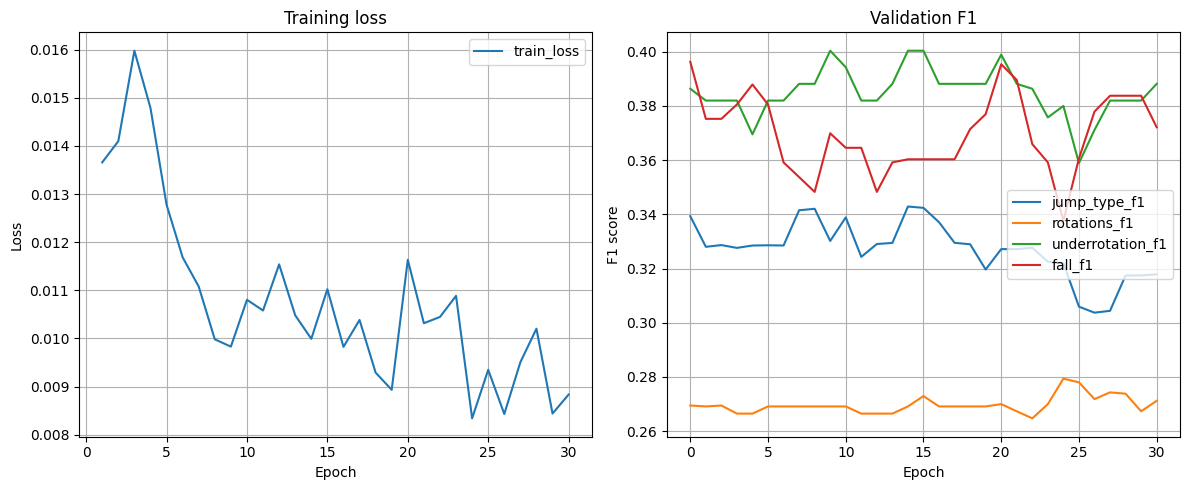

In [16]:
model = train_cached(
    train_loader=train_loader,
    # device="cpu",
    val_loader=val_loader,
    model=model[0],
    epochs=30,
    lr=1e-5,
    print_every=4,
    plot_every=32,
)

In [17]:
model = train_cached(
    train_loader=train_loader,
    # device="cpu",
    val_loader=val_loader,
    model=model,
    epochs=300,
    lr=1e-7,
    print_every=4,
    plot_every=32,
)

device = device(type='mps')


AttributeError: 'tuple' object has no attribute 'to'

In [ ]:
video_features = []
video_labels = []

frames_features: torch.Tensor 
label: torch.Tensor 

for el in tqdm(dataloader):
    frames_features, labels, metas = el
    labels = list(labels)
    print(f"{frames_features.shape = }")
    print(f"{labels = }")
    video_features.extend(frames_features.tolist())
    video_labels.extend(labels)
    